Work plan: Write a collaborative filtering algorithm, that receives a 2 dimensional matrix (nm, nu) (number of movies  x  number of users) that represents a rating given to each movie by each user. They range from 0.5 to 5, with 0.5 steps. 0 means that the movie has not been rated yet by the user - and the goal is to calculate the estimate of that opinion. The algorithm, calculates for each movie a vector, and for each user a vector: movies vector represents some description of the movie, users vectors represent their movie taste. The dot product of these vectors plus a bias terms produces an estimate of the rating the user might give to the movie.

Key problem:
We only have ratings given by each user to each movie. We can't simply look at each user differently and try to predict their next opinion - because we only have names of the movies, no specific features that let us charactirize the users taste. We cant also only look at the movies. We must here look at the whole picture - how each user looks at each movie, and how the movies are characterized by mass.

Solution:
We can create for each user its own "movie preferences" vector (nfeatures,1). And for each movie its own "movie description" vector (nfeatures,1). Using gradient descent, we can combine two linear regression models (one that assumes that each movie has features, and fits parameters that let us estimate users opinions. And other one that assumes that each user has features, and fits parameters that let us estimate the opinion) into one that SIMULTANEOUSLY updates these to vectors parameters (movie preferences/movie description) so taht the dot product of those 2 + bias term give us the estimate opinion.
Keep in mind that it is only possible because using gradient descents magic power, we can always calculate the best possible n + n features (and bias term) at the point. And doing that step by step will lead us to succession. Now we dont have a pretty bowl with one local minimum, that is a global minimum at the sime time - like we did with normal linear regression. Now we actullay have many local minimums and even more saddle points. But gradient descent easly escapes from saddle points, and luckily for us those local minimums are all equally good!



Why LINEAR regression?:
Well thanks to the simplicity of our world - and our behaviour, movie ratings and our opinion on them move linearly. This means that if i like the movie 6% less than last time, i will give it a 6% worse opinion. It moves in a LINEAR manner. The bias here is usefull when for eg. we have an optimistic person, that gives lets say always higher stars. Or an passimistic one that gives always higher stars. Their patterns and likings can be explained linearly, but with a bias term.

We also add regulazation, so that the vectors are pushed to be less biased (less overfitted). We try to centralize them using squared lambda regulazation. Doing so will make the gradient descent see that making the weights not be so "one way focused" in space, come with less cost.

In [32]:
import numpy as np

Loading the data...:

In [33]:
from recsys_utils import *
import tensorflow as tf
from tensorflow import keras

In [34]:
Y, R = load_ratings_small()
#  Useful Values
num_movies, num_users = Y.shape
num_features = 100

# Set Initial Parameters (W, X), use tf.Variable to track these variables
tf.random.set_seed(1234) # for consistent results
W = tf.Variable(tf.random.normal((num_users,  num_features),dtype=tf.float64),  name='W')
X = tf.Variable(tf.random.normal((num_movies, num_features),dtype=tf.float64),  name='X')
b = tf.Variable(tf.random.normal((1,          num_users),   dtype=tf.float64),  name='b')

# Instantiate an optimizer.
optimizer = keras.optimizers.Adam(learning_rate=1e-1) ## we will use this later in our custom gradient descent algorithm.
print("Y", Y.shape, "R", R.shape)
print("X", X.shape)
print("W", W.shape)
print("b", b.shape)
print("num_features", num_features)
print("num_movies",   num_movies)
print("num_users",    num_users)

Y (4778, 443) R (4778, 443)
X (4778, 100)
W (443, 100)
b (1, 443)
num_features 100
num_movies 4778
num_users 443


We shall also of course normalize our data as always. This also makes it work when a user who has never rated anything comes in. His parameters are updated sorely from the normalization. Which makes it zero. Then we add the mean to it at the and. (to everthing to undo the normalization)

In [40]:
counts = R.sum(axis=1, keepdims=True)  # shape (nm, 1)

# suma ocen na film (nm, 1) – zera nie przeszkadzają, bo i tak Y*R
sums = (Y * R).sum(axis=1, keepdims=True)

# średnia filmu (nm, 1) — unikamy dzielenia przez 0
mu = np.divide(sums, counts, out=np.zeros_like(sums), where=(counts != 0))

# odejmujemy średnią tylko tam, gdzie R=1
Ynorm = (Y - mu) * R
Ymean = mu

nu - 443
nm - 4778
Y - opinions
X - movies vectors
W,b - users vectors
n - number of features (100)

Now we develop the cost function that will later on gradient descent use to reduce the cost at each step.

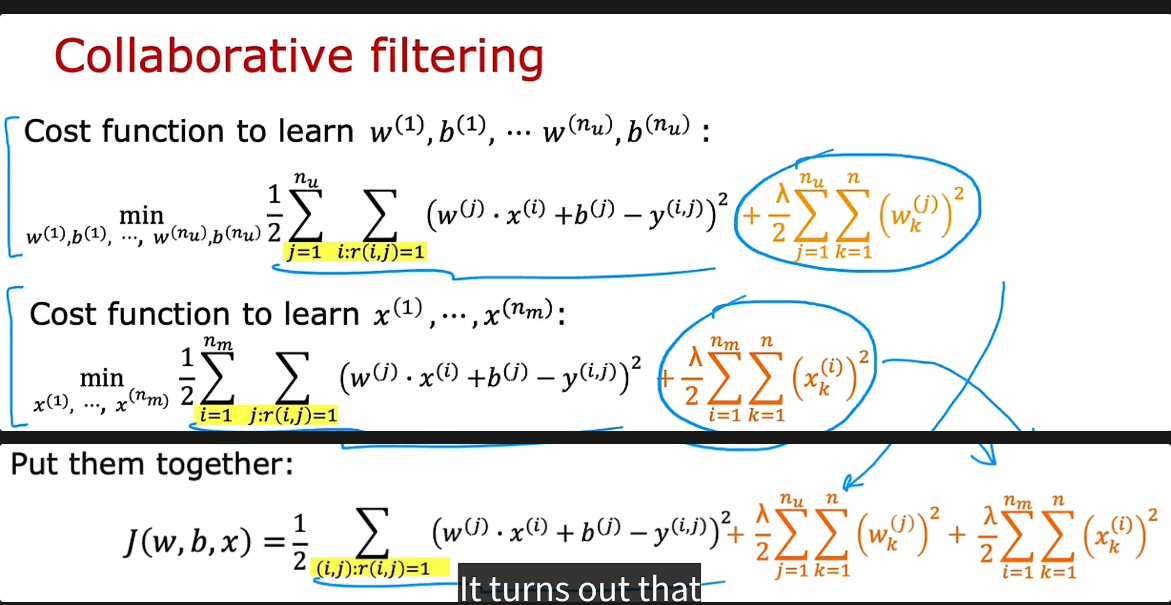

In [41]:
#najpierw zrobie for loop implementation
def cofi_cost_function(X, W, b, Y, R, lambda_):
    """
    Returns the cost for the content-based filtering
    Args:
      X (ndarray (num_movies,num_features)): matrix of item features
      W (ndarray (num_users,num_features)) : matrix of user parameters
      b (ndarray (1, num_users)            : vector of user parameters
      Y (ndarray (num_movies,num_users)    : matrix of user ratings of movies
      R (ndarray (num_movies,num_users)    : matrix, where R(i, j) = 1 if the i-th movies was rated by the j-th user
      lambda_ (float): regularization parameter
    Returns:
      J (float) : Cost
    """
    J = 0
    nu = len(X[0])
    nm = len(X)
    num_features = len(W[1])
    for i in range(nm):
        movie_vector = X[i]
        #regulazation: movie vectors
        for ifeature in range(num_features):
            J += movie_vector[ifeature]**2
        
        for j in range(nu):
            #regulazation: user vectors
            for ifeature in range(num_features):
                J += W[j,ifeature]**2
            if R[i,j] == 1:
                user_vector = W[j]
                user_bias = b[0,j]

                MSE = ((user_vector @ movie_vector + user_bias) - Y[i,j])**2
                J += MSE
        
    return (J*lambda_)/2

vectorized implementation

In [44]:
def cofi_cost_func_v(X, W, b, Y, R, lambda_):
    """
    Returns the cost for the content-based filtering
    Vectorized for speed. Uses tensorflow operations to be compatible with custom training loop.
    Args:
      X (ndarray (num_movies,num_features)): matrix of item features
      W (ndarray (num_users,num_features)) : matrix of user parameters
      b (ndarray (1, num_users)            : vector of user parameters
      Y (ndarray (num_movies,num_users)    : matrix of user ratings of movies
      R (ndarray (num_movies,num_users)    : matrix, where R(i, j) = 1 if the i-th movies was rated by the j-th user
      lambda_ (float): regularization parameter
    Returns:
      J (float) : Cost
    """
    #moge pomnozyc w pewnym momencie razy R. aby dac zerowe wartosci tam gdzie nie chce

    # dostaje dla kazdego filmu, i dla kazdego uzytkownika @ (num_movies,num_users) + bias.
    # odejmuje Y. -> robie squared i sumuje.
     # 1) Predykcja wszystkich ocen
    # (nm, nf) @ (nu, nf)^T -> (nm, nu)
    Y_hat = tf.matmul(X, W, transpose_b=True) + b

    # 2) Błąd tylko tam gdzie mamy rating (maskowanie przez R)
    # err: (nm, nu)
    err = (Y_hat - Y) * R

    # 3) Koszt MSE
    J = 0.5 * tf.reduce_sum(tf.square(err))

    # 4) Regularizacja L2 (bez biasu)
    reg = 0.5 * lambda_ * (tf.reduce_sum(tf.square(X)) + tf.reduce_sum(tf.square(W)))
    
    return J + reg

Now we create a custom gradient descent algorithm. 

Gradient descent:
 - compute the derivatives of each variable
 - update each variable so that the loss is smaller
   

Tenser flow has a marvelous capacity of calculating them for you. This is shown below. within the tf.GradientTape() section, operations made on TENSERFLOW variables are tracked. When tape.gradient() is called, it returns the gradient of the loss relative to the tracked variables. The gradients then can be substracted from variables using an optimizer.

In [49]:
iterations = 200
lambda_ = 1
for iter in range(iterations):
    # Use TensorFlow’s GradientTape
    # to record the operations used to compute the cost 
    with tf.GradientTape() as tape:

        # Compute the cost (forward pass included in cost)
        cost_value = cofi_cost_func_v(X, W, b, Ynorm, R, lambda_)

    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss
    grads = tape.gradient( cost_value, [X,W,b] ) ## to jest bardzo ciekawe. wykorzystujac nasza funkcje kosztu, mowimy z recpetem do jakich zmiennych chcemy j update

    # Run one step of gradient descent by updating
    # the value of the variables to minimize the loss.
    optimizer.apply_gradients( zip(grads, [X,W,b]) )

    # Log periodically.
    if iter % 20 == 0:
        print(f"Training loss at iteration {iter}: {cost_value:0.1f}")

Training loss at iteration 0: 1772.0
Training loss at iteration 20: 1771.1
Training loss at iteration 40: 1770.3
Training loss at iteration 60: 1769.6
Training loss at iteration 80: 1769.0
Training loss at iteration 100: 1768.4
Training loss at iteration 120: 1767.9
Training loss at iteration 140: 1767.4
Training loss at iteration 160: 1766.9
Training loss at iteration 180: 1766.5


Reccomendations:

In [55]:
# Make a prediction using trained weights and biases
p = np.matmul(X.numpy(), np.transpose(W.numpy())) + b.numpy()

#restore the mean
pm = p + Ymean

for i in range(100):
    for j in range(20):
        if R[i,j] == 1:    
            print(f"prediction: {pm[i,j]}, reality: {Y[i,j]}")

prediction: 1.1657219839639237, reality: 1.0
prediction: 2.6656837056810043, reality: 3.0
prediction: 4.716293530575864, reality: 5.0
prediction: 2.016589054013206, reality: 2.0
prediction: 4.475823413588635, reality: 4.5
prediction: 4.013013086646747, reality: 4.0
prediction: 2.9575488300977097, reality: 3.0
prediction: 3.0187441485960895, reality: 3.0
prediction: 2.128245121096576, reality: 2.0
prediction: 3.492784399541139, reality: 3.5
prediction: 2.099576728620168, reality: 2.0
prediction: 3.8551532433393216, reality: 4.0
prediction: 1.73172716141171, reality: 2.0
prediction: 1.5775133509041512, reality: 1.5
prediction: 3.9382017571390824, reality: 4.0
prediction: 4.407110956747171, reality: 4.5
prediction: 3.488290642286553, reality: 3.5
prediction: 2.33159913074344, reality: 2.0
prediction: 2.0609367916339787, reality: 2.0
prediction: 1.9544373797465728, reality: 2.0
prediction: 2.1443640648675584, reality: 2.0
prediction: 2.1288926450353474, reality: 2.0
prediction: 0.599815092